## 저장된 데이터셋을 불러와서 로봇에 액션을 전송하는 데모


In [89]:
# 라이브러리 로드
import logging
import time
from pathlib import Path

from lerobot.robots.so_follower.so_follower import SO100Follower
from lerobot.robots.so_follower.config_so_follower import SO100FollowerConfig
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.utils.robot_utils import precise_sleep

import yaml
import pandas as pd
import numpy as np

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Store global variables for use across cells
globals_dict = {
    'robot': None,
    'dataset': None,
    'dataset_root': None,
}

In [90]:
# 설정
config_path = Path("/home/choyunsang/lerobot/config.yaml")

if not config_path.exists():
        print(f"❌ Config file not found: {config_path}")
        print("   Using default values instead...")
        # Fallback to defaults
        port = "/dev/ttyACM1"
        DATASET_NAME = "SO100_VR_teleoperation"
        DATASET_ROOT = Path.home() / "Dataset"  # 데이터셋이 저장된 경로
        fps = 30
        kp = 0.5

else:
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    
    # Extract robot configuration (including cameras!)
    robot_config_dict = config.get('robot', {})
    port = robot_config_dict.get('port', "/dev/ttyACM0")
    DATASET_NAME = config["dataset"]["task_name"]
    DATASET_ROOT = Path(config["dataset"]["root"])
    fps = config.get('fps', 30)
    kp = config.get('kp', 0.5)

print(f"✅ Config loaded successfully from {config_path}")
print(f"   PORT: {port}")
print(f"   DATASET_NAME: {DATASET_NAME}")
print(f"   DATASET_ROOT: {DATASET_ROOT}")
print(f"   FPS: {fps}")

✅ Config loaded successfully from /home/choyunsang/lerobot/config.yaml
   PORT: /dev/ttyACM0
   DATASET_NAME: SO100_VR_teleoperation
   DATASET_ROOT: /home/choyunsang/Dataset
   FPS: 30


In [91]:
# [1] 로봇 연결

print("🔄 Connecting to SO100...")

try:    
    robot_config = SO100FollowerConfig(port=port)
    robot = SO100Follower(robot_config)
    
    robot.connect()
    logger.info(f"✅ Robot connected successfully on {port}")
    
    # 🎯 Verify cameras are connected
    if hasattr(robot, 'cameras') and len(robot.cameras) > 0:
        logger.info(f"✅ Cameras connected: {list(robot.cameras.keys())}")
        print(f"✅ Cameras connected: {list(robot.cameras.keys())}")
    else:
        logger.warning("⚠️  No cameras connected to robot")
        print(f"⚠️  No cameras connected to robot")
    
    if robot.is_calibrated:
        logger.info("✅ Robot is calibrated")
    else:
        logger.warning("⚠️  Robot needs calibration")
    
    # Store robot reference
    globals_dict['robot'] = robot
    
    print("\n" + "="*70)
    print("✅ ROBOT CONNECTED AND READY")
    print("="*70)
    
except Exception as e:
    logger.error(f"❌ Robot connection failed: {e}")
    import traceback
    traceback.print_exc()

🔄 Connecting to SO100...
⚠️  No cameras connected to robot

✅ ROBOT CONNECTED AND READY


In [92]:
# 사용할 데이터 선택
chunk_num = 0
file_num = 0

In [93]:
# [2] Parquet 파일 확인

logger.info(f"📁 Parquet 데이터셋 로드 중: {DATASET_NAME}")
try:
    # 최신 타임스탬프 데이터셋 찾기
    dataset_dirs = DATASET_ROOT.joinpath(DATASET_NAME)
    dataset_dirs = dataset_dirs.joinpath("data", f"chunk-{chunk_num:03d}")

    if not dataset_dirs:
        logger.error(f"❌ {DATASET_NAME} 데이터셋을 찾을 수 없습니다!")
        logger.info(f"   {DATASET_ROOT} 디렉토리 확인: {list(DATASET_ROOT.glob('*'))}")
    
    print(f"   - 존재 여부: {dataset_dirs.exists()}")
    
    df = pd.read_parquet(dataset_dirs / f"file-{file_num:03d}.parquet")

    timestamp = df['timestamp']

    action_state = df['action']
    
    joint0 = [row[0] for row in action_state]
    joint1 = [row[1] for row in action_state]
    joint2 = [row[2] for row in action_state]
    joint3 = [row[3] for row in action_state]
    joint4 = [row[4] for row in action_state]
    joint5 = [row[5] for row in action_state]

    print(f"✅ Parquet file loaded successfully: {dataset_dirs / f'file-{file_num:03d}.parquet'}")
    print(f"   - Total frames: {len(df)}")
    print(f"   - Timestamp range: {timestamp.min()} to {timestamp.max()}")
    print(f"   - Sample joint values (first frame):")
    print(f"      joint0: {joint0[0]:.2f}, joint1: {joint1[0]:.2f}, joint2: {joint2[0]:.2f}, joint3: {joint3[0]:.2f}, joint4: {joint4[0]:.2f}, joint5: {joint5[0]:.2f}")
    
    globals_dict['dataset'] = {'shoulder_pan': joint0, "shoulder_lift": joint1, "elbow_flex": joint2, "wrist_flex": joint3, "wrist_roll": joint4, "gripper": joint5}
except Exception as e:
    logger.error(f"❌ 데이터셋 로드 실패: {e}")
    import traceback
    traceback.print_exc()

   - 존재 여부: True
✅ Parquet file loaded successfully: /home/choyunsang/Dataset/SO100_VR_teleoperation/data/chunk-000/file-000.parquet
   - Total frames: 237
   - Timestamp range: 0.0 to 23.600000381469727
   - Sample joint values (first frame):
      joint0: -3.32, joint1: -0.09, joint2: 3.56, joint3: 0.68, joint4: -0.20, joint5: 23.18


In [94]:
# deploy할 프레임 범위 설정
start_frame = 0
end_frame = 120


🖼️  Parquet 파일에서 이미지 읽기

📷 발견된 이미지 컬럼: ['observation.images.right', 'observation.images.head']

✅ 선택된 컬럼: observation.images.right
   데이터 타입: <class 'dict'>
   딕셔너리 키: ['bytes', 'path']

   딕셔너리 내용 (타입):
     - bytes: bytes (306401 bytes)
     - path: str = frame-000000.png

✅ Bytes 데이터 발견: 'bytes' (306401 bytes)

✅ Bytes 데이터 발견: 'bytes' (394295 bytes)

✅ 이미지 출력 완료!


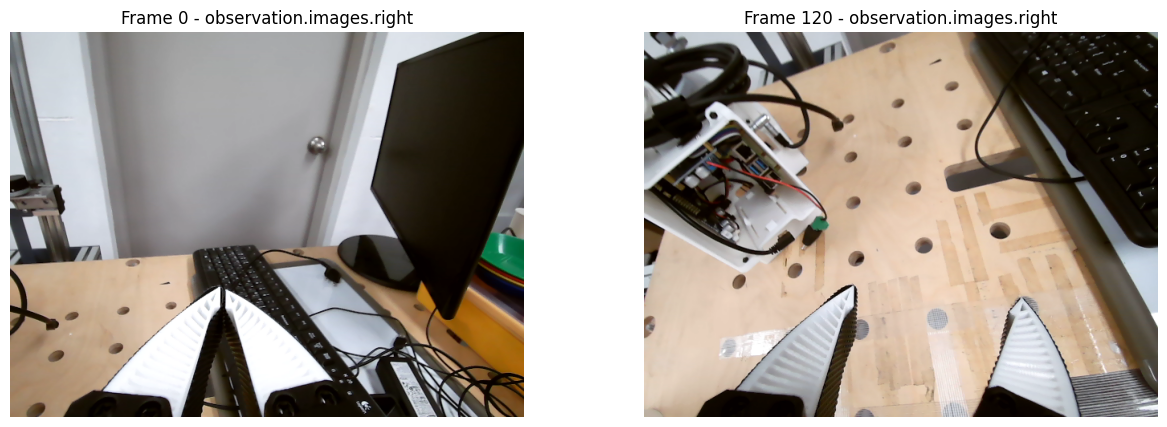

In [95]:
# 시작 끝 이미지 확인
import matplotlib.pyplot as plt
from PIL import Image
import io
import cv2
import pandas as pd

df = pd.read_parquet(dataset_dirs / f"file-{file_num:03d}.parquet")

print("\n" + "=" * 70)
print("🖼️  Parquet 파일에서 이미지 읽기")
print("=" * 70)

# 이미지 관련 컬럼 찾기
image_columns = [col for col in df.columns if 'image' in col.lower()]
print(f"\n📷 발견된 이미지 컬럼: {image_columns}")

if image_columns:
    # 첫 번째 이미지 컬럼에서 첫 번째 프레임의 이미지 가져오기
    first_image_col = image_columns[0]
    first_image_data = df[first_image_col].iloc[start_frame]
    last_image_data = df[first_image_col].iloc[end_frame]
    
    print(f"\n✅ 선택된 컬럼: {first_image_col}")
    print(f"   데이터 타입: {type(first_image_data)}")
    
    # 딕셔너리 구조 확인
    if isinstance(first_image_data, dict):
        print(f"   딕셔너리 키: {list(first_image_data.keys())}")
        print(f"\n   딕셔너리 내용 (타입):")
        for key, value in first_image_data.items():
            if isinstance(value, bytes):
                print(f"     - {key}: bytes ({len(value)} bytes)")
            else:
                print(f"     - {key}: {type(value).__name__} = {value}")
        
        try:
            # bytes 데이터 찾기
            first_image_bytes = None
            first_bytes_key = None

            last_image_bytes = None
            last_bytes_key = None
            
            for key, value in first_image_data.items():
                if isinstance(value, bytes):
                    first_image_bytes = value
                    first_bytes_key = key
                    break
            
            for key, value in last_image_data.items():
                if isinstance(value, bytes):
                    last_image_bytes = value
                    last_bytes_key = key
                    break

            if first_image_bytes and last_image_bytes:
                print(f"\n✅ Bytes 데이터 발견: '{first_bytes_key}' ({len(first_image_bytes)} bytes)")
                print(f"\n✅ Bytes 데이터 발견: '{last_bytes_key}' ({len(last_image_bytes)} bytes)")
                
                # bytes를 PIL Image로 변환
                image1 = Image.open(io.BytesIO(first_image_bytes))
                image2 = Image.open(io.BytesIO(last_image_bytes))
                
                fig, axes = plt.subplots(1, 2, figsize=(15, 5))

                # 각 축(axes)에 이미지 출력
                axes[0].imshow(image1)
                axes[0].set_title(f"Frame {start_frame} - {first_image_col}")
                axes[0].axis('off')
                axes[1].imshow(image2)
                axes[1].set_title(f"Frame {end_frame} - {first_image_col}")
                axes[1].axis('off')
                
                print(f"\n✅ 이미지 출력 완료!")
            else:
                # bytes가 없으면 비디오 파일에서 추출
                print(f"\n📹 Bytes 데이터가 없어, 비디오 파일에서 추출 시도...")
                
                video_path = None
                frame_index = 0
                
                if 'path' in first_image_data:
                    video_path = first_image_data['path']
                    frame_index = first_image_data.get('frame_index', 0)
                elif 'video_path' in first_image_data:
                    video_path = first_image_data['video_path']
                    frame_index = first_image_data.get('frame_index', 0)
                
                if video_path:
                    print(f"   비디오 파일: {video_path}")
                    print(f"   프레임 인덱스: {frame_index}")
                    
                    # 비디오 파일 경로 구성
                    video_file = DATASET_ROOT.joinpath(DATASET_NAME) / "videos" / video_path
                    
                    if video_file.exists():
                        print(f"   파일 존재: ✅")
                        
                        # OpenCV로 비디오 프레임 추출
                        cap = cv2.VideoCapture(str(video_file))
                        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
                        ret, frame = cap.read()
                        cap.release()
                        
                        if ret:
                            # BGR을 RGB로 변환
                            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                            
                            print(f"   이미지 크기: {image.shape}")
                            
                            # 이미지 표시
                            plt.figure(figsize=(10, 8))
                            plt.imshow(image)
                            plt.title(f"Frame {frame_index} - {first_image_col}")
                            plt.axis('off')
                            plt.tight_layout()
                            plt.show()
                            
                            print(f"✅ 이미지 출력 완료!")
                        else:
                            print(f"⚠️  프레임 추출 실패")
                    else:
                        print(f"   파일 경로: {video_file}")
                        print(f"   파일 존재: ❌")
                else:
                    print(f"⚠️  비디오 경로 정보를 찾을 수 없습니다.")
                
        except Exception as e:
            print(f"⚠️  이미지 처리 중 오류: {e}")
            import traceback
            traceback.print_exc()
    else:
        print(f"   데이터 타입: {type(first_image_data).__name__}")
        print("⚠️  딕셔너리가 아닌 다른 형식입니다.")
else:
    print("⚠️  이미지 컬럼을 찾을 수 없습니다.")

In [96]:
# [3] Zero Pose 이동 (keyboard control 코드 참조)

# Joint calibration coefficients (0_so100_keyboard_joint_control.py 참조)
JOINT_CALIBRATION = [
    ['shoulder_pan', 6.0, 1.0],      # Joint1: zero position offset, scale factor
    ['shoulder_lift', 2.0, 0.97],     # Joint2
    ['elbow_flex', 0.0, 1.05],        # Joint3
    ['wrist_flex', 0.0, 0.94],        # Joint4
    ['wrist_roll', 0.0, 0.5],        # Joint5
    ['gripper', 0.0, 1.0],           # Joint6
]

def apply_joint_calibration(joint_name, raw_position):
    """
    Joint 보정 계수 적용 (keyboard control 참조)
    """
    for joint_cal in JOINT_CALIBRATION:
        if joint_cal[0] == joint_name:
            offset = joint_cal[1]
            scale = joint_cal[2]
            calibrated_position = (raw_position - offset) * scale
            return calibrated_position
    return raw_position

def move_to_zero_position(robot, duration=3.0, kp=0.5, control_freq=50):
    """
    P 제어로 로봇을 zero position으로 이동
    (0_so100_keyboard_joint_control.py의 move_to_zero_position 참조)
    """
    logger.info("🎯 P 제어로 zero position으로 이동 중...")
    
    # Zero position targets
    zero_positions = {
        'shoulder_pan': 0.0,
        'shoulder_lift': 0.0,
        'elbow_flex': 0.0,
        'wrist_flex': 0.0,
        'wrist_roll': 0.0,
        'gripper': 0.0
    }
    
    total_steps = int(duration * control_freq)
    step_time = 1.0 / control_freq
    
    logger.info(f"⏱️  {duration}초 동안 P 제어로 이동 (Kp={kp}, {control_freq}Hz)")
    
    for step in range(total_steps):
        # 현재 로봇 상태 획득
        current_obs = robot.get_observation()
        current_positions = {}
        
        for key, value in current_obs.items():
            if key.endswith('.pos'):
                motor_name = key.removesuffix('.pos')
                # 보정 계수 적용
                calibrated_value = apply_joint_calibration(motor_name, value)
                current_positions[motor_name] = calibrated_value
        
        # P 제어 계산
        robot_action = {}
        for joint_name, target_pos in zero_positions.items():
            if joint_name in current_positions:
                current_pos = current_positions[joint_name]
                error = target_pos - current_pos
                
                # P 제어: output = Kp * error
                control_output = kp * error
                new_position = current_pos + control_output
                robot_action[f"{joint_name}.pos"] = new_position
        
        # 로봇에 액션 전송
        if robot_action:
            robot.send_action(robot_action)
        
        # 진행률 표시
        if step % (control_freq // 2) == 0:
            progress = (step / total_steps) * 100
            print(f"   진행률: {progress:.1f}%")
        
        time.sleep(step_time)
    
    logger.info("✅ Zero position 이동 완료!")

# 로봇 zero position으로 이동
try:
    robot = globals_dict.get('robot')
    if robot is None:
        logger.error("❌ 로봇이 연결되지 않았습니다. [1] 로봇 연결 섹션을 먼저 실행해주세요.")
    else:
        move_to_zero_position(robot, duration=3.0, kp=0.5, control_freq=50)
        print("="*70)
        print("✅ ZERO POSITION READY")
        print("="*70)
except Exception as e:
    logger.error(f"❌ Zero position 이동 실패: {e}")
    import traceback
    traceback.print_exc()

   진행률: 0.0%
   진행률: 16.7%
   진행률: 33.3%
   진행률: 50.0%
   진행률: 66.7%
   진행률: 83.3%
✅ ZERO POSITION READY


In [ ]:
# [4] Deploy - Parquet 파일의 관절 각도를 로봇에 전송

logger.info("🚀 Parquet 데이터의 액션을 로봇에 전송하기 시작합니다...")

try:
    robot = globals_dict.get('robot')
    dataset = globals_dict.get('dataset')
    
    if robot is None:
        logger.error("❌ 로봇이 연결되지 않았습니다. [1] 로봇 연결 섹션을 먼저 실행해주세요.")
    elif dataset is None:
        logger.error("❌ 데이터셋이 로드되지 않았습니다. [2] Parquet 파일 확인 섹션을 먼저 실행해주세요.")
    else:
        print(f"📁 데이터셋 로드 완료: {DATASET_NAME}")
        print(f"   - 총 프레임 수: {len(dataset['shoulder_pan'])}")
        # 첫 번째 에피소드 인덱스 범위
        print(f"   - 실행할 프레임 범위: {start_frame} ~ {end_frame}")
        
        num_frames = end_frame - start_frame
        
        # 실행할 프레임 수 설정 (전체 또는 일부)
        num_frames_to_run = num_frames  # 전체 실행
                
        step_time = 1.0 / fps
        start_time = time.perf_counter()
        
        for frame_idx in range(start_frame, start_frame + num_frames_to_run):
            loop_start = time.perf_counter()
            
            # 데이터셋에서 프레임 가져오기
            current_obs = robot.get_observation() # 현재 프레임의 joint 값 가져오기
            current_positions = {}

            for key, value in current_obs.items():
                if key.endswith('.pos'):
                    motor_name = key.removesuffix('.pos')
                    # Apply calibration coefficients
                    calibrated_value = apply_joint_calibration(motor_name, value)
                    current_positions[motor_name] = calibrated_value
            # 액션 추출 (액션 필드명: "action_<arm>_<joint>.pos")

            # P control calculation
            robot_action = {}
            for joint_name, target_pos in dataset.items():
                if joint_name in current_positions:
                    current_pos = current_positions[joint_name]
                    error = target_pos[frame_idx] - current_pos
                    
                    # P control: output = Kp * error
                    control_output = kp * error
                    
                    # Convert control output to position command
                    new_position = current_pos + control_output
                    robot_action[f"{joint_name}.pos"] = new_position


            if not dataset:
                logger.warning(f"⚠️  프레임 {frame_idx}: 액션이 없습니다")
                continue
            
            # 로봇에 액션 전송
            try:
                robot.send_action(robot_action)
                
                # 진행률 표시 (10개 프레임마다)
                frame_num = frame_idx - start_frame + 1
                if frame_num % 10 == 0 or frame_num == 1 or frame_num == num_frames_to_run:
                    elapsed_total = time.perf_counter() - start_time
                    logger.info(
                        f"📤 프레임 {frame_num:04d}/{num_frames_to_run:04d} | "
                        f"경과시간: {elapsed_total:.2f}s | "
                        f"액션 수: {len(robot_action)}"
                    )
                
            except Exception as e:
                logger.error(f"❌ 프레임 {frame_idx}: 액션 전송 실패 - {e}")
                continue
            
            # fps 유지 (정확한 타이밍)
            elapsed = time.perf_counter() - loop_start
            sleep_time = step_time - elapsed
            if sleep_time > 0:
                precise_sleep(sleep_time)
        
        elapsed_total = time.perf_counter() - start_time
        logger.info(f"✅ 액션 전송 완료!")
        logger.info(f"   ⏱️  총 소요시간: {elapsed_total:.2f}초")
        logger.info(f"   📊 평균 FPS: {num_frames_to_run / elapsed_total:.2f}")
        
        print("\n" + "="*70)
        print("✅ DEPLOYMENT COMPLETED")
        print("="*70)
    
except Exception as e:
    logger.error(f"❌ 액션 전송 중 오류: {e}")
    import traceback
    traceback.print_exc()

📁 데이터셋 로드 완료: SO100_VR_teleoperation
   - 총 프레임 수: 237
action data is {'shoulder_pan': [np.float32(-3.3186812), np.float32(-3.3186812), np.float32(-3.3186812), np.float32(-3.010989), np.float32(-2.6593406), np.float32(-2.4395604), np.float32(-2.1318681), np.float32(-1.7802198), np.float32(-1.5604396), np.float32(-1.2967033), np.float32(-1.2087913), np.float32(-1.1648352), np.float32(-1.0329671), np.float32(-0.989011), np.float32(-0.85714287), np.float32(-0.7692308), np.float32(-0.63736266), np.float32(-0.5934066), np.float32(-0.50549453), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.float32(-0.46153846), np.fl

## !! 아래 코드는 로봇 팔 토크가 갑자기 풀리니 로봇 잠깐 잡고 있기 !!

In [ ]:
# [5] 정리 - 로봇 연결 해제 및 글로벌 변수 초기화
print("🔄 Cleaning up...")

robot = globals_dict.get('robot')


try:
    if robot:
        robot.disconnect()
        logger.info("✅ Robot disconnected")
        
    # Give threads time to stop
    time.sleep(0.5)
    
    print("\n" + "="*70)
    print("✅ ALL SYSTEMS SAFELY SHUT DOWN")
    print("="*70)
    
except Exception as e:
    logger.error(f"❌ Cleanup error: {e}")
    traceback.print_exc()

# Reset globals
globals_dict['robot'] = None
globals_dict['event_loop_thread'] = None
globals_dict['event_loop'] = None

🔄 Cleaning up...

✅ ALL SYSTEMS SAFELY SHUT DOWN
